# Simple SPEA for Capacitated p-Median (Bi-objective)

This notebook implements a **simple** Strength Pareto based evolutionary algorithm to solve a bi-objective capacitated p-median problem:
- Minimize demand-weighted service distance
- Maximize facility dispersion (minimum pairwise distance among opened medians)

Decisions are restricted to opening medians at customer locations.

In [8]:
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Any

import numpy as np
import matplotlib.pyplot as plt


In [9]:
@dataclass
class Instance:
    instance_id: int
    best_known: float
    n: int
    p: int
    capacity: int
    customer_ids: np.ndarray
    xy: np.ndarray
    demand: np.ndarray


def load_instances(path: str) -> Dict[int, Instance]:
    with open(path, "r", encoding="utf-8") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    i = 0
    instances = {}
    while i < len(lines):
        head = lines[i].split()
        instance_id = int(head[0])
        best_known = float(head[1])
        i += 1

        n, p, cap = map(int, lines[i].split())
        i += 1

        ids, xy, dem = [], [], []
        for _ in range(n):
            cid, x, y, d = map(int, lines[i].split())
            ids.append(cid)
            xy.append((x, y))
            dem.append(d)
            i += 1

        instances[instance_id] = Instance(
            instance_id=instance_id,
            best_known=best_known,
            n=n,
            p=p,
            capacity=cap,
            customer_ids=np.array(ids, dtype=int),
            xy=np.array(xy, dtype=float),
            demand=np.array(dem, dtype=float),
        )

    return instances


instances = load_instances("p_median_capacitated.txt")
print(f"Loaded {len(instances)} instances")
print("IDs:", sorted(instances.keys())[:])

Loaded 18 instances
IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


In [10]:
def pairwise_dist_matrix(xy: np.ndarray) -> np.ndarray:
    diff = xy[:, None, :] - xy[None, :, :]
    return np.sqrt(np.sum(diff * diff, axis=2))


def greedy_capacity_assignment(
    medians: np.ndarray,
    demand: np.ndarray,
    dist: np.ndarray,
    capacity: float,
) -> Tuple[bool, float, float]:
    k = len(medians)
    remaining = np.full(k, float(capacity))
    total_weighted = 0.0
    total_unweighted = 0.0

    order = np.argsort(-demand)  # large demands first

    for customer in order:
        d = demand[customer]
        feasible = np.where(remaining >= d)[0]
        if feasible.size == 0:
            return False, float("inf"), float("inf")

        local_d = dist[customer, medians[feasible]]
        j = int(np.argmin(local_d))
        pick_local = int(feasible[j])
        chosen_dist = float(local_d[j])

        total_unweighted += chosen_dist
        total_weighted += float(d) * chosen_dist
        remaining[pick_local] -= d

    return True, total_weighted, total_unweighted

def dispersion_min_pair(medians: np.ndarray, dist: np.ndarray) -> float:
    if len(medians) < 2:
        return 0.0
    sub = dist[np.ix_(medians, medians)]
    upper = sub[np.triu_indices(len(medians), k=1)]
    return float(np.min(upper))


def evaluate_solution(sol: Tuple[int, ...], inst: Instance, dist: np.ndarray):
    med = np.array(sol, dtype=int)

    feasible, weighted_cost, unweighted_cost = greedy_capacity_assignment(
        med, inst.demand, dist, inst.capacity
    )
    if not feasible:
        return float("inf"), float("-inf"), (float("inf"), float("inf")), float("inf")

    disp = dispersion_min_pair(med, dist)

    # SPEA minimization objectives (choose which service you want to optimize)
    obj = (weighted_cost, -disp)   # keep optimizing weighted service
    return weighted_cost, disp, obj, unweighted_cost


In [11]:
def dominates(a, b) -> bool:
    return all(x <= y for x, y in zip(a, b)) and any(x < y for x, y in zip(a, b))


def strength_raw_fitness(objs: List[Tuple[float, float]]):
    n = len(objs)
    S = [0] * n
    R = [0] * n

    for i in range(n):
        if math.isinf(objs[i][0]):
            continue
        for j in range(n):
            if i != j and dominates(objs[i], objs[j]):
                S[i] += 1

    for i in range(n):
        if math.isinf(objs[i][0]):
            R[i] = 10**9
            continue
        total = 0
        for j in range(n):
            if i != j and dominates(objs[j], objs[i]):
                total += S[j]
        R[i] = total

    return S, R


def nd_indices(objs: List[Tuple[float, float]]):
    idx = []
    for i in range(len(objs)):
        if math.isinf(objs[i][0]):
            continue
        dom = False
        for j in range(len(objs)):
            if i != j and dominates(objs[j], objs[i]):
                dom = True
                break
        if not dom:
            idx.append(i)
    return idx


def truncate_by_spacing(indices: List[int],
                        objs: List[Tuple[float, float]],
                        target_size: int) -> List[int]:
    keep = indices[:]

    while len(keep) > target_size:
        points = np.array([objs[i] for i in keep], dtype=float)

        # Normalize each objective to [0, 1] to avoid scale dominance
        mins = points.min(axis=0)
        maxs = points.max(axis=0)
        span = np.maximum(maxs - mins, 1e-12)  # avoid divide-by-zero
        points = (points - mins) / span

        # Pairwise distances in normalized objective space
        diff = points[:, None, :] - points[None, :, :]
        dmat = np.sqrt(np.sum(diff * diff, axis=2))
        np.fill_diagonal(dmat, np.inf)

        # Crowding measure: nearest neighbor distance
        nearest = np.min(dmat, axis=1)

        # Remove the most crowded (smallest nearest-neighbor distance)
        remove_pos = int(np.argmin(nearest))
        keep.pop(remove_pos)

    return keep


def repair_solution(sol: List[int], n: int, p: int) -> Tuple[int, ...]:
    # Remove duplicates
    sol = list(dict.fromkeys(sol))

    if len(sol) < p:
        chosen = set(sol)
        available = [x for x in range(n) if x not in chosen]
        # sample without replacement
        sol.extend(random.sample(available, p - len(sol)))
    elif len(sol) > p:
        sol = random.sample(sol, p)

    return tuple(sorted(sol))


def crossover(a: Tuple[int, ...], b: Tuple[int, ...], n: int, p: int) -> Tuple[int, ...]:
    common = set(a) & set(b)
    pool = list(set(a) | set(b))

    child = list(common)
    child_set = set(child)

    random.shuffle(pool)
    for g in pool:
        if len(child) >= p:
            break
        if g not in child_set:
            child.append(g)
            child_set.add(g)

    return repair_solution(child, n, p)


def mutate(sol: Tuple[int, ...], n: int, p: int, pm: float) -> Tuple[int, ...]:
    if random.random() >= pm:
        return sol

    s = list(sol)
    out = random.choice(s)
    s.remove(out)

    chosen = set(s)
    candidates = [x for x in range(n) if x not in chosen]
    s.append(random.choice(candidates))

    return tuple(sorted(s))


def tournament(pop: List[Tuple[int, ...]], fit: List[float]) -> Tuple[int, ...]:
    i, j = random.sample(range(len(pop)), 2)
    return pop[i] if fit[i] <= fit[j] else pop[j]


def random_solution(n: int, p: int) -> Tuple[int, ...]:
    return tuple(sorted(random.sample(range(n), p)))


In [12]:
import math
import random
import numpy as np

def spea(
    inst: Instance,
    pop_size: int = 80,
    archive_size: int = 40,
    generations: int = 120,
    pm: float = 0.2,
    seed: int = 42,
):
    random.seed(seed)
    np.random.seed(seed)

    dist = pairwise_dist_matrix(inst.xy)

    P = [random_solution(inst.n, inst.p) for _ in range(pop_size)]
    A = []
    history = []

    for gen in range(generations):
        U = P + A

        eval_full = [evaluate_solution(sol, inst, dist) for sol in U]
        objs = [x[2] for x in eval_full]   # (service, -disp)
        service = [x[0] for x in eval_full]
        disp = [x[1] for x in eval_full]

        _, R = strength_raw_fitness(objs)

        nd = nd_indices(objs)
        if len(nd) > archive_size:
            selected_idx = truncate_by_spacing(nd, objs, archive_size)
        else:
            selected_idx = nd[:]
            if len(selected_idx) < archive_size:
                rest = [i for i in range(len(U)) if i not in selected_idx]
                rest.sort(key=lambda i: R[i])
                selected_idx += rest[: archive_size - len(selected_idx)]

        # New archive
        A = [U[i] for i in selected_idx]

        # Fitness values for archive members, derived from the combined set U
        A_fit = [R[i] for i in selected_idx]

        new_P = []
        while len(new_P) < pop_size:
            p1 = tournament(A, A_fit)
            p2 = tournament(A, A_fit)
            c = crossover(p1, p2, inst.n, inst.p)
            c = mutate(c, inst.n, inst.p, pm)
            new_P.append(c)

        P = new_P

        finite_service = [v for v in service if not math.isinf(v)]
        best_service = min(finite_service) if finite_service else float("inf")
        best_disp = max([v for v in disp if v > -1e20], default=float("-inf"))
        history.append((gen, best_service, best_disp, len(nd)))

    # Evaluate final archive once
    final_eval = [evaluate_solution(sol, inst, dist) for sol in A]
    final_data = [
    {
        "solution": sol,
        "service": e[0],                 # weighted
        "dispersion": e[1],
        "obj": e[2],
        "unweighted_service": e[3],      # comparable to best_known
    }
    for sol, e in zip(A, final_eval)
    if not math.isinf(e[0])
]

    objs = [d["obj"] for d in final_data]
    nd = nd_indices(objs)
    pareto = [final_data[i] for i in nd]
    pareto.sort(key=lambda z: (z["service"], -z["dispersion"]))

    return pareto, history

In [13]:
import math
import numpy as np
from joblib import Parallel, delayed

def run_one_seed_joblib(instance_id, seed, spea_kwargs):
    inst = instances[instance_id]
    pareto, history = spea(inst, seed=seed, **spea_kwargs)

    best_known = float(inst.best_known)

    if not pareto:
        return {
            "seed": seed,
            "best_known": best_known,
            "best_weighted": math.inf,
            "best_unweighted": math.inf,
            "gap_pct_unweighted": math.inf,
            "pareto_size": 0,
        }

    best_weighted = min(d["service"] for d in pareto)

    # This key must exist in pareto dicts
    best_unweighted = min(d["unweighted_service"] for d in pareto)

    gap_pct = ((best_unweighted - best_known) / best_known) * 100.0 if best_known != 0 else math.inf

    return {
        "seed": seed,
        "best_known": best_known,
        "best_weighted": float(best_weighted),
        "best_unweighted": float(best_unweighted),
        "gap_pct_unweighted": float(gap_pct),
        "pareto_size": len(pareto),
    }


def run_seeds_joblib(instance_id, seeds, n_jobs=-1, **spea_kwargs):
    spea_kwargs = dict(spea_kwargs)  # ensure picklable
    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(run_one_seed_joblib)(instance_id, int(s), spea_kwargs) for s in seeds
    )
    results.sort(key=lambda r: r["seed"])
    return results


def summarize_unweighted(results):
    unw = np.array([r["best_unweighted"] for r in results], dtype=float)
    gaps = np.array([r["gap_pct_unweighted"] for r in results], dtype=float)
    finite = np.isfinite(unw)

    return {
        "runs": len(results),
        "feasible_runs": int(finite.sum()),
        "median_best_unweighted": float(np.median(unw[finite])) if finite.any() else math.inf,
        "min_best_unweighted": float(np.min(unw[finite])) if finite.any() else math.inf,
        "median_gap_pct": float(np.median(gaps[finite])) if finite.any() else math.inf,
        "min_gap_pct": float(np.min(gaps[finite])) if finite.any() else math.inf,
    }


# ---- Usage ----
instance_id = 16
seeds = range(2)

results = run_seeds_joblib(
    instance_id,
    seeds,
    n_jobs=-1,
    pop_size=160,
    archive_size=80,
    generations=240,
    pm=0.2,
)

# Print header
print("seed  best_known  best_unweighted  gap%_unw   best_weighted   pareto")
for r in results:
    print(
        f"{r['seed']:>4d}  "
        f"{r['best_known']:>9.2f}  "
        f"{r['best_unweighted']:>14.2f}  "
        f"{r['gap_pct_unweighted']:>8.2f}  "
        f"{r['best_weighted']:>13.2f}  "
        f"{r['pareto_size']:>6d}"
    )

print("\nSummary:", summarize_unweighted(results))

seed  best_known  best_unweighted  gap%_unw   best_weighted   pareto
   0     954.00         1057.62     10.86       10592.98      80
   1     954.00         1057.61     10.86       10661.58      80

Summary: {'runs': 2, 'feasible_runs': 2, 'median_best_unweighted': 1057.6136259621303, 'min_best_unweighted': 1057.609176091438, 'median_gap_pct': 10.860967081984308, 'min_gap_pct': 10.860500638515516}


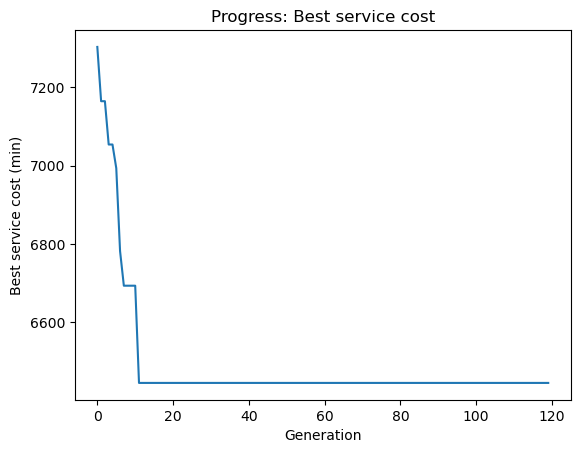

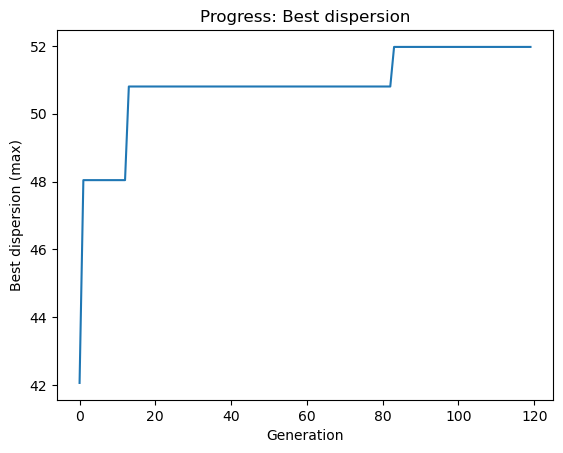

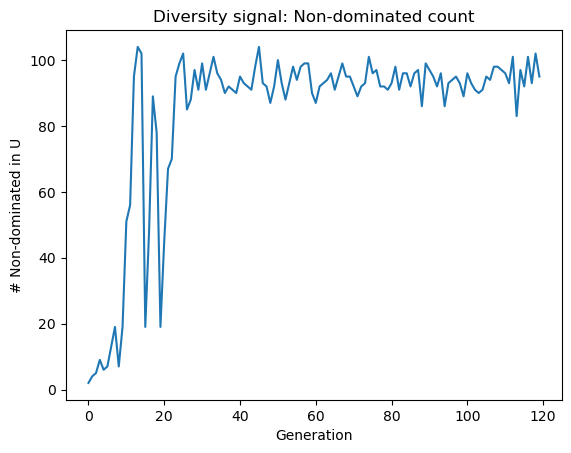

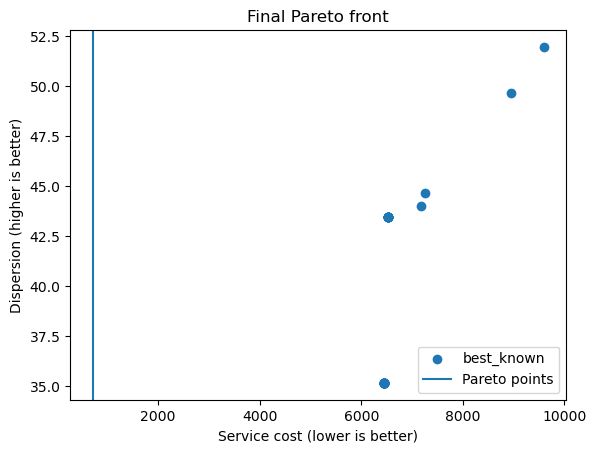

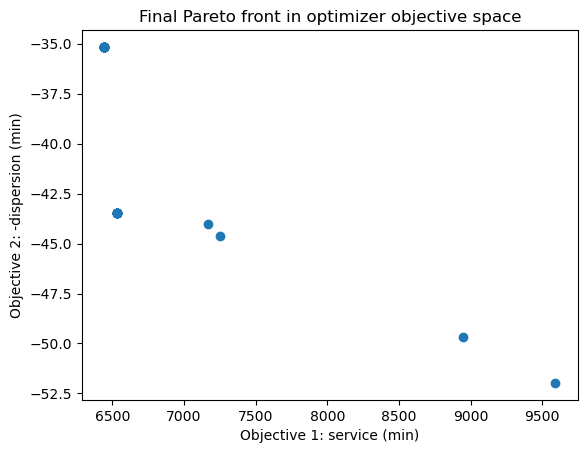

In [14]:
def plot_history(history):
    arr = np.array(history, dtype=float)
    gen = arr[:, 0]
    best_service = arr[:, 1]
    best_disp = arr[:, 2]
    nd_count = arr[:, 3]

    plt.figure()
    plt.plot(gen, best_service)
    plt.xlabel("Generation")
    plt.ylabel("Best service cost (min)")
    plt.title("Progress: Best service cost")
    plt.show()

    plt.figure()
    plt.plot(gen, best_disp)
    plt.xlabel("Generation")
    plt.ylabel("Best dispersion (max)")
    plt.title("Progress: Best dispersion")
    plt.show()

    plt.figure()
    plt.plot(gen, nd_count)
    plt.xlabel("Generation")
    plt.ylabel("# Non-dominated in U")
    plt.title("Diversity signal: Non-dominated count")
    plt.show()

def plot_pareto(pareto, inst=None):
    if not pareto:
        print("Pareto set is empty (no feasible solutions).")
        return

    service = [d["service"] for d in pareto]
    disp = [d["dispersion"] for d in pareto]

    plt.figure()
    plt.scatter(service, disp)
    plt.xlabel("Service cost (lower is better)")
    plt.ylabel("Dispersion (higher is better)")
    plt.title("Final Pareto front")

    # Optional reference: best_known service cost (if that's what it represents)
    if inst is not None and inst.best_known is not None:
        plt.axvline(inst.best_known)
        plt.legend(["best_known", "Pareto points"])

    plt.show()

def plot_pareto_objective_space(pareto):
    if not pareto:
        print("Pareto set is empty (no feasible solutions).")
        return

    x = [d["obj"][0] for d in pareto]  # service
    y = [d["obj"][1] for d in pareto]  # -disp

    plt.figure()
    plt.scatter(x, y)
    plt.xlabel("Objective 1: service (min)")
    plt.ylabel("Objective 2: -dispersion (min)")
    plt.title("Final Pareto front in optimizer objective space")
    plt.show()

pareto, history = spea(instances[1], pop_size=80, archive_size=40, generations=120, pm=0.2, seed=42)

plot_history(history)
plot_pareto(pareto, inst=instances[1])
plot_pareto_objective_space(pareto)  # optional

In [15]:
# --- Run on one benchmark instance ---
INSTANCE_ID = 16

inst = instances[INSTANCE_ID]
pareto, history = spea(
    inst,
    pop_size=80,
    archive_size=40,
    generations=120,
    pm=0.2,
    seed=7,
)

print(f"Instance: {inst.instance_id} | best-known (single objective): {inst.best_known}")
print(f"Pareto solutions found: {len(pareto)}")

for i, s in enumerate(pareto[:10], start=1):
    mids = [inst.customer_ids[j] for j in s['solution']]
    print(f"{i:2d}. service={s['service']:.2f}, dispersion={s['dispersion']:.2f}, medians={mids}")

Instance: 16 | best-known (single objective): 954.0
Pareto solutions found: 40
 1. service=11307.23, dispersion=22.02, medians=[np.int64(10), np.int64(44), np.int64(47), np.int64(61), np.int64(65), np.int64(67), np.int64(68), np.int64(77), np.int64(85), np.int64(100)]
 2. service=11316.50, dispersion=23.35, medians=[np.int64(9), np.int64(10), np.int64(44), np.int64(47), np.int64(61), np.int64(65), np.int64(68), np.int64(77), np.int64(85), np.int64(100)]
 3. service=11316.50, dispersion=23.35, medians=[np.int64(9), np.int64(10), np.int64(44), np.int64(47), np.int64(61), np.int64(65), np.int64(68), np.int64(77), np.int64(85), np.int64(100)]
 4. service=11316.50, dispersion=23.35, medians=[np.int64(9), np.int64(10), np.int64(44), np.int64(47), np.int64(61), np.int64(65), np.int64(68), np.int64(77), np.int64(85), np.int64(100)]
 5. service=11765.15, dispersion=24.04, medians=[np.int64(14), np.int64(44), np.int64(47), np.int64(55), np.int64(61), np.int64(65), np.int64(68), np.int64(82), np.

In [16]:
def service_gap_report(pareto: List[Dict[str, Any]], inst: Instance) -> Dict[str, float]:
    """
    pareto: output from spea (list of dicts with keys: service, dispersion, ...)
    inst.best_known: benchmark service cost (from file)
    """
    best_known = float(inst.best_known)

    if not pareto:
        return {
            "best_known": best_known,
            "best_service": math.inf,
            "abs_gap": math.inf,
            "pct_gap": math.inf,
        }

    best_unw = min(d["unweighted_service"] for d in pareto)
    best_service = min(d["service"] for d in pareto)
    abs_gap = best_service - best_known
    pct_gap = (best_unw / best_known) * 100.0 if best_known != 0 else math.inf

    return {
        "best_known": best_known,
        "best_service": float(best_service),
        "abs_gap": float(abs_gap),
        "pct_gap": float(pct_gap),
        "best_unweighted": float(best_unw),
    }

# Example usage:
pareto, history = spea(instances[1], seed=42)
rep = service_gap_report(pareto, instances[1])
print(
    f"Instance {instances[1].instance_id}: "
    f"best_service={rep['best_service']:.2f}, "
    f"best_known={rep['best_known']:.2f}, "
    f"best_unweighted={rep['best_unweighted']:.2f}, "
    f"gap={rep['abs_gap']:.2f} ({rep['pct_gap']:.2f}%)"
)


def gap_over_seeds(inst: Instance, seeds=range(20)) -> Dict[str, float]:
    gaps = []
    bests = []
    for s in seeds:
        pareto, _ = spea(inst, seed=s)
        rep = service_gap_report(pareto, inst)
        gaps.append(rep["pct_gap"])
        bests.append(rep["best_service"])

    gaps = np.array(gaps, dtype=float)
    bests = np.array(bests, dtype=float)

    return {
        "median_pct_gap": float(np.median(gaps)),
        "mean_pct_gap": float(np.mean(gaps)),
        "min_pct_gap": float(np.min(gaps)),
        "max_pct_gap": float(np.max(gaps)),
        "median_best_service": float(np.median(bests)),
    }

summary = gap_over_seeds(instances[1], seeds=range(30))
print(summary)

Instance 1: best_service=6444.71, best_known=713.00, best_unweighted=762.18, gap=5731.71 (106.90%)
{'median_pct_gap': 108.174079578421, 'mean_pct_gap': 110.1581809418716, 'min_pct_gap': 106.89754858492526, 'max_pct_gap': 117.53410498518252, 'median_best_service': 6454.312855384856}


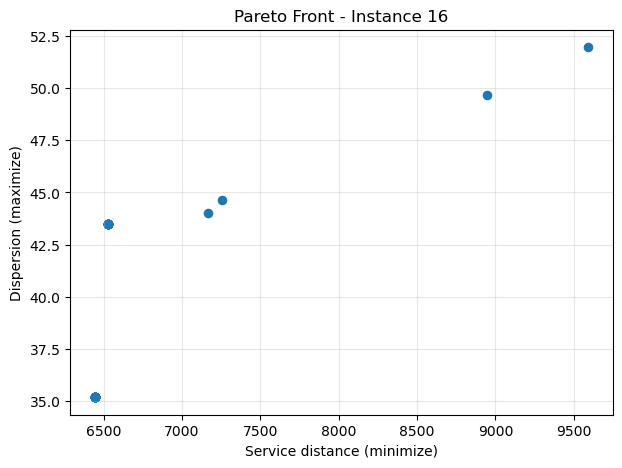

In [17]:
# Pareto scatter: lower service is better, higher dispersion is better.
x = [s["service"] for s in pareto]
y = [s["dispersion"] for s in pareto]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=35)
plt.xlabel("Service distance (minimize)")
plt.ylabel("Dispersion (maximize)")
plt.title(f"Pareto Front - Instance {inst.instance_id}")
plt.grid(alpha=0.3)
plt.show()

In [18]:
# Optional: run all 18 instances quickly (smaller generations)
# results = {}
# for iid, ins in instances.items():
#     p, _ = spea_simple(ins, pop_size=60, archive_size=30, generations=80, pm=0.2, seed=7)
#     results[iid] = p
#
# for iid in sorted(results):
#     if results[iid]:
#         best_service = min(z['service'] for z in results[iid])
#         best_disp = max(z['dispersion'] for z in results[iid])
#         print(f"Instance {iid:2d}: pareto={len(results[iid]):2d}, best_service={best_service:.2f}, best_disp={best_disp:.2f}")
#     else:
#         print(f"Instance {iid:2d}: no feasible solution found")